# 01 - Visualising the three networks

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

MAPPING_NAMES = {
    "ring": "Anell Regular",
    "er": "Erdos-Reny",
    "ws": "Watts–Strogatz"
}
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from src.smallworld.networks import build_all
from src.smallworld.plotting import draw_networks_grid, to_pyvis, save_pyvis

1. Build the three networks

In [2]:
N, k, beta = 20, 4, 0.1
graphs = build_all(N=N, k=k, beta=beta)

for name, G in graphs.items():
    avg_deg = 2 * G.number_of_edges() / G.number_of_nodes()
    print(f"{name:>4}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, <deg>={avg_deg:.2f}")

ring: nodes=20, edges=40, <deg>=4.00
  er: nodes=20, edges=32, <deg>=3.20
  ws: nodes=20, edges=40, <deg>=4.00


2. Static comparison

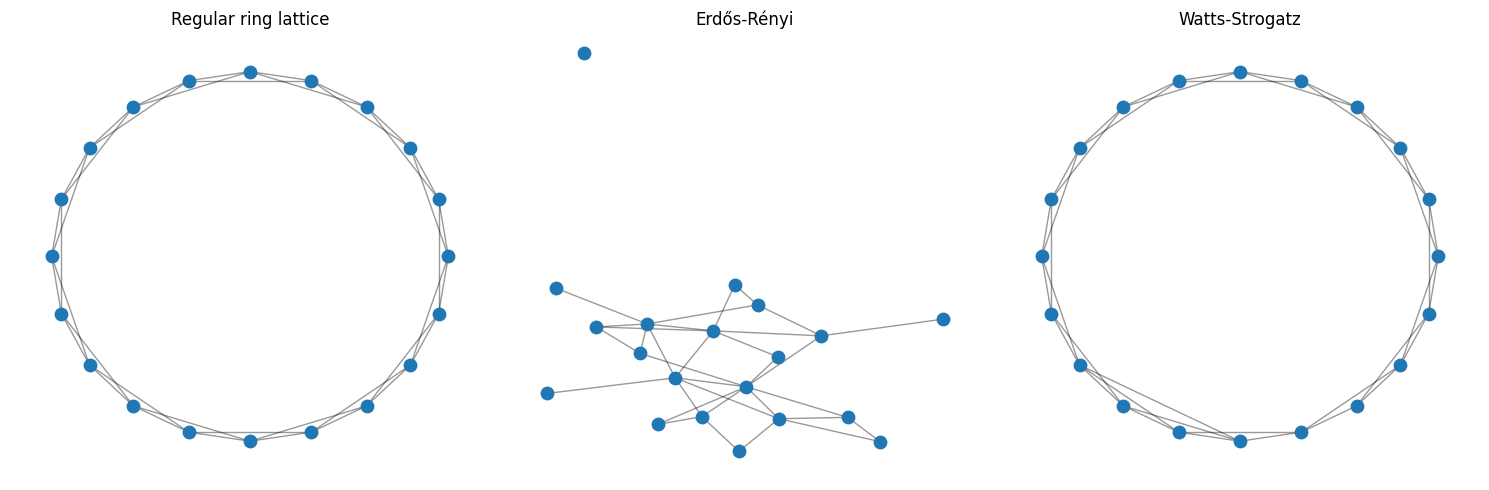

In [3]:
fig = draw_networks_grid(graphs, save=FIGURES / "01_three_networks.png")
plt.show()

3. Interactive visualisations

In [4]:
layouts = {"ring": "circular", "er": "spring", "ws": "circular"}

for name, G in graphs.items():
    net = to_pyvis(G, layout=layouts[name], physics=True)
    out = save_pyvis(net, FIGURES / f"01_{name}.html")
    print(f"saved {out.relative_to(ROOT)}")

saved figures\01_ring.html
saved figures\01_er.html
saved figures\01_ws.html


4.  Simulation

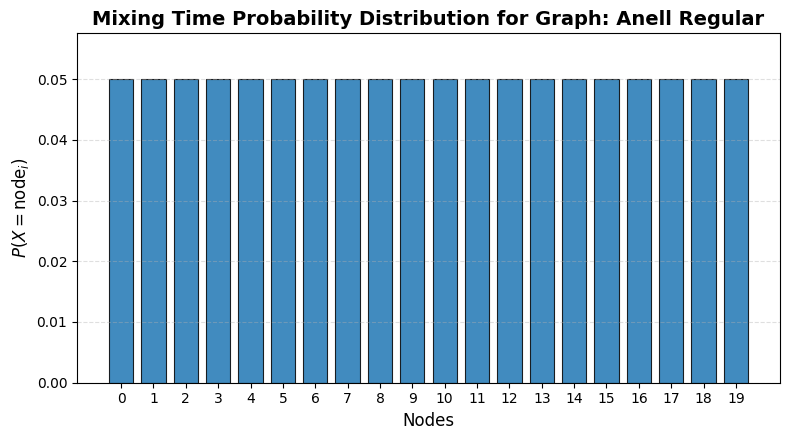

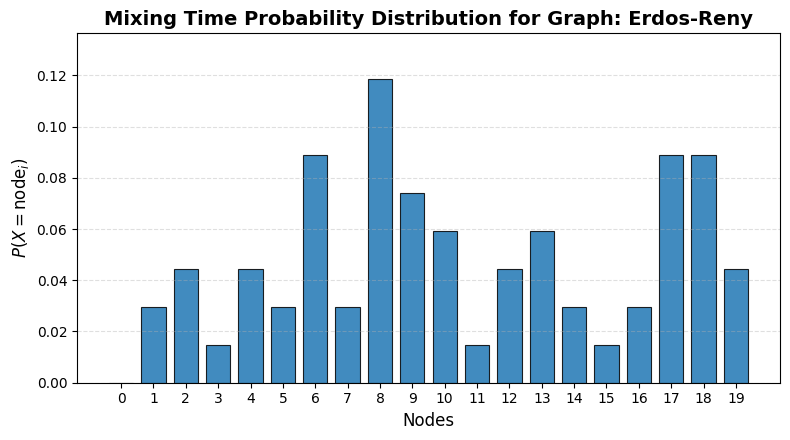

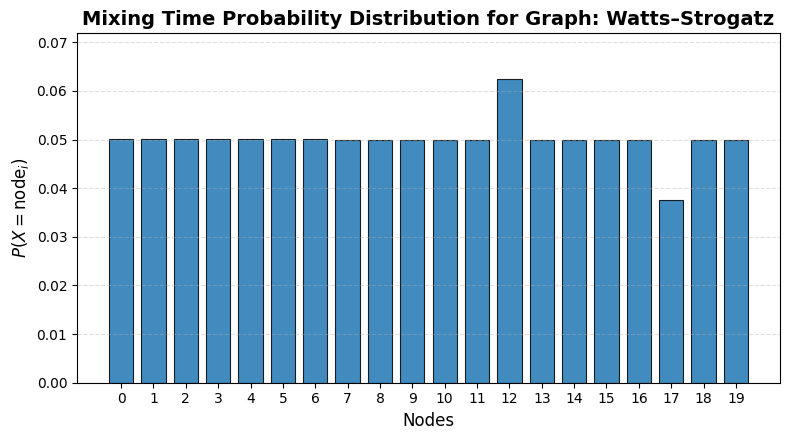

In [5]:
from src.smallworld.simulation import mixing_time, plot_mixing_time_distribution

# ====== Mixing Time ======
n_sims = 50
for name, graph in graphs.items():
    out_dic, _ = mixing_time(G=graph, n_simulations=n_sims)
    all_probs = [dic["distribution"] for dic in out_dic.values()]
    plot_mixing_time_distribution(all_probs, name_graph=MAPPING_NAMES[name])